In [5]:
# dependencies

from Bio import AlignIO
from Bio import SeqIO
import re
import pandas as pd
from ete3 import NCBITaxa
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import ast

In [6]:
# results in FASTA form into dataframe

def pfam_results(results_input):
    data = {'accession': [], 'taxon': [], 'seq identifier': [], 'I Helix': []}
    with open(results_input) as fp:
        for record in SeqIO.parse(fp, "fasta"):
            seqident = re.findall(r"\|(?P<sequence_id>\w+)\|", record.id)
            accession = record.description
            taxon = re.findall(r"OX=(\d+)", record.description)
            sequence = str(record.seq)

            # attaching to dictionary
            data['seq identifier'].append(", ".join(seqident))
            data['accession'].append(accession)
            data['taxon'].append(", ".join(taxon))
            data['I Helix'].append(sequence)

    df = pd.DataFrame.from_dict(data)
    return df

In [7]:
# Converting HMM search output for pfam data to FASTA file
input = '/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.aln'
outfile_fasta = '/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.fasta'

with open(input) as infile:
    alignment = AlignIO.read(infile, 'stockholm')

SeqIO.write(alignment, outfile_fasta, 'fasta')

278757

In [8]:
pfam_r1 = pfam_results('/home/alecia/chapter3-repo/output/hmm_search_1/pfam/3/ihelixhits_e_0p001_z__T_.fasta')
pfam_r2 = pfam_results('/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.fasta')

In [10]:
r1r2_merged_pfam = (pd.merge(pfam_r1, pfam_r2, how='outer', on=['seq identifier', 'taxon'])
                    .fillna(0)
                    .drop_duplicates(subset=['seq identifier']))
r1r2_merged_pfam

,accession_x,taxon,seq identifier,I Helix_x,accession_y,I Helix_y
0,tr|A0A498MRP4|A0A498MRP4_LABRO/720-751 [subseq...,84645,A0A498MRP4,-DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY,tr|A0A498MRP4|A0A498MRP4_LABRO/1164-1198 [subs...,-NMEGL--VISCL-D-V-I-E--A----G------TE--T-TAT--...
21,tr|A0A182Y3M0|A0A182Y3M0_ANOST/316-347 [subseq...,30069,A0A182Y3M0,-EEIAAQAF-VF-F-FG--G---FET--S--T-T--TLT-CALHLLAKY,tr|A0A182Y3M0|A0A182Y3M0_ANOST/313-348 [subseq...,LTFEEI--AAQAF-V-F-F-F--G----G------FE--T-STT--...
85,tr|A0A9Q0JPW7|A0A9Q0JPW7_9ROSI/567-595 [subseq...,218843,A0A9Q0JPW7,-RYLRDIIL-NI-M-FA--G---KDT--S--A-N--TIS-WFFYML---,tr|A0A9Q0JPW7|A0A9Q0JPW7_9ROSI/564-599 [subseq...,MNDRYL--RDIIL-N-I-M-F--A----G------KD--T-SAN--...
109,tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/475-505 [subseq...,1594786,A0A8J4WTT4,--DVYGSVA-EL-L-LA--G---VDT--T--S-I--TLM-WALYLLSQN,tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/471-506 [subseq...,MSKKDV--YGSVA-E-L-L-L--A----G------VD--T-TSI--...
145,tr|A0A553R2M7|A0A553R2M7_9TELE/301-332 [subseq...,623744,A0A553R2M7,-ENLMMTVM-NL-F-VA--G---TDT--T--G-T--TLR-WGLMLMAKY,tr|A0A553R2M7|A0A553R2M7_9TELE/300-333 [subseq...,--DENL--MMTVM-N-L-F-V--A----G------TD--T-TGT--...
...,...,...,...,...,...,...
294301,0,100035,A0A7C8I5D7,0,tr|A0A7C8I5D7|A0A7C8I5D7_9PLEO/294-325 [subseq...,----VL--RDQIV-Q-A-M-M--A----S------TE--T-TGS--...
294302,0,50452,A0A087GH04,0,tr|A0A087GH04|A0A087GH04_ARAAL/284-319 [subseq...,FTHENV--KSMIL-D-I-V-V--P----G------TD--T-AAA--...
294303,0,1001938,A0A1Y2UC39,0,tr|A0A1Y2UC39|A0A1Y2UC39_9PEZI/289-316 [subseq...,---------MEAI-L-F-T-V--A----G------GD--T-TST--...
294304,0,1355477,A0A0E4FSG9,0,tr|A0A0E4FSG9|A0A0E4FSG9_9BRAD/239-274 [subseq...,LSDAEL--ISMLW-G-M-L-L--G----G------FV--T-TAA--...


In [11]:
# If sequence in I_Helix y, take the acid alcohol - if not, take the acid alcohol in I Helix x

result_data = []

for index, row in r1r2_merged_pfam.iterrows():
    if row['I Helix_y'] != 0:
        acid = row['I Helix_y'][36]
        alc = row['I Helix_y'][39]
    else:
        acid = row['I Helix_x'][24]
        alc = row['I Helix_x'][25]

    # Append a dictionary with relevant information to the result_data list
    result_data.append({
        'accession': row['accession_y'],
        'sequence_y': row['I Helix_y'],
        'sequence_x': row['I Helix_x'],
        'seq identifier': row['seq identifier'],
        'acid': acid,
        'alc': alc,
        'taxon': row['taxon'],
    })


# Create a DataFrame from the result_data list
result_df = pd.DataFrame(result_data)


In [13]:
ncbi = NCBITaxa()

In [14]:
# Function to fetch lineage and ranks using NCBITaxa
def get_lineage_and_ranks(taxon_id):
    try:
        lineage = ncbi.get_lineage(taxon_id)  # List of lineage taxids
        ranks = ncbi.get_rank(lineage)  # Get ranks for the lineage
        
        # Map the taxid to its corresponding name and rank
        lineage_and_ranks = {ncbi.get_taxid_translator([taxid])[taxid]: ranks[taxid] 
                             for taxid in lineage if taxid in ranks}
        
        return lineage_and_ranks
    except:
        return None  # Return None if the ID is not found or there is an error

In [ ]:
# Apply ncbi taxa to dataframe in chunks to access lineage and ranks

result_df["lineage_and_ranks"] = result_df["taxon"].apply(lambda x: get_lineage_and_ranks(int(x)) if pd.notna(x) else None)

result_df.to_csv('r1r2_pfam_acidalc_taxon.csv')

In [15]:
input = '/home/alecia/chapter3-repo/analysis/pfam_tax/r1r2_pfam_acidalc_taxon.csv'

with open(input) as f:
    pfam_with_taxa = pd.read_csv(input)

pfam_with_taxa

/home/alecia/anaconda3/envs/taxon/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3550: DtypeWarning: Columns (3) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,Unnamed: 0,accession,sequence_y,sequence_x,seq identifier,acid,alc,taxon,lineage_and_ranks
0,0,tr|A0A498MRP4|A0A498MRP4_LABRO/1164-1198 [subs...,-NMEGL--VISCL-D-V-I-E--A----G------TE--T-TAT--...,-DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY,A0A498MRP4,E,T,84645,"{'root': 'no rank', 'cellular organisms': 'no ..."
1,1,tr|A0A182Y3M0|A0A182Y3M0_ANOST/313-348 [subseq...,LTFEEI--AAQAF-V-F-F-F--G----G------FE--T-STT--...,-EEIAAQAF-VF-F-FG--G---FET--S--T-T--TLT-CALHLLAKY,A0A182Y3M0,E,T,30069,"{'root': 'no rank', 'cellular organisms': 'no ..."
2,2,tr|A0A9Q0JPW7|A0A9Q0JPW7_9ROSI/564-599 [subseq...,MNDRYL--RDIIL-N-I-M-F--A----G------KD--T-SAN--...,-RYLRDIIL-NI-M-FA--G---KDT--S--A-N--TIS-WFFYML---,A0A9Q0JPW7,D,T,218843,"{'root': 'no rank', 'cellular organisms': 'no ..."
3,3,tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/471-506 [subseq...,MSKKDV--YGSVA-E-L-L-L--A----G------VD--T-TSI--...,--DVYGSVA-EL-L-LA--G---VDT--T--S-I--TLM-WALYLLSQN,A0A8J4WTT4,D,T,1594786,"{'root': 'no rank', 'cellular organisms': 'no ..."
4,4,tr|A0A553R2M7|A0A553R2M7_9TELE/300-333 [subseq...,--DENL--MMTVM-N-L-F-V--A----G------TD--T-TGT--...,-ENLMMTVM-NL-F-VA--G---TDT--T--G-T--TLR-WGLMLMAKY,A0A553R2M7,D,T,623744,"{'root': 'no rank', 'cellular organisms': 'no ..."
...,...,...,...,...,...,...,...,...,...
287225,287225,tr|A0A7C8I5D7|A0A7C8I5D7_9PLEO/294-325 [subseq...,----VL--RDQIV-Q-A-M-M--A----S------TE--T-TGS--...,0,A0A7C8I5D7,E,T,100035,"{'root': 'no rank', 'cellular organisms': 'no ..."
287226,287226,tr|A0A087GH04|A0A087GH04_ARAAL/284-319 [subseq...,FTHENV--KSMIL-D-I-V-V--P----G------TD--T-AAA--...,0,A0A087GH04,D,T,50452,"{'root': 'no rank', 'cellular organisms': 'no ..."
287227,287227,tr|A0A1Y2UC39|A0A1Y2UC39_9PEZI/289-316 [subseq...,---------MEAI-L-F-T-V--A----G------GD--T-TST--...,0,A0A1Y2UC39,D,T,1001938,"{'root': 'no rank', 'cellular organisms': 'no ..."
287228,287228,tr|A0A0E4FSG9|A0A0E4FSG9_9BRAD/239-274 [subseq...,LSDAEL--ISMLW-G-M-L-L--G----G------FV--T-TAA--...,0,A0A0E4FSG9,V,T,1355477,"{'root': 'no rank', 'cellular organisms': 'no ..."


In [16]:
# Define standard taxonomic ranks
tax_ranks = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']

# Function to flip dict and extract ranks
def extract_taxonomy(tax_str):
    try:
        # Parse only if it's a string
        tax_dict = ast.literal_eval(tax_str) if isinstance(tax_str, str) else tax_str
        # Flip key-values: {'Metazoa': 'kingdom'} → {'kingdom': 'Metazoa'}
        flipped = {v.strip(): k.strip() for k, v in tax_dict.items()}
        # Extract ranks in the desired order
        return [flipped.get(rank, None) for rank in tax_ranks]
    except Exception as e:
        print(f"Error parsing: {tax_str}\n{e}")  # Debugging info
        return [None] * len(tax_ranks)

# Apply extraction function
pfam_with_taxa[tax_ranks] = pfam_with_taxa['lineage_and_ranks'].apply(lambda x: pd.Series(extract_taxonomy(x)))

# Save or view the result
pfam_with_taxa.to_csv('taxonomy_parsed.csv', index=False)
print(pfam_with_taxa.head())

   Unnamed: 0                                          accession  \
0           0  tr|A0A498MRP4|A0A498MRP4_LABRO/1164-1198 [subs...   
1           1  tr|A0A182Y3M0|A0A182Y3M0_ANOST/313-348 [subseq...   
2           2  tr|A0A9Q0JPW7|A0A9Q0JPW7_9ROSI/564-599 [subseq...   
3           3  tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/471-506 [subseq...   
4           4  tr|A0A553R2M7|A0A553R2M7_9TELE/300-333 [subseq...   

                                          sequence_y  \
0  -NMEGL--VISCL-D-V-I-E--A----G------TE--T-TAT--...   
1  LTFEEI--AAQAF-V-F-F-F--G----G------FE--T-STT--...   
2  MNDRYL--RDIIL-N-I-M-F--A----G------KD--T-SAN--...   
3  MSKKDV--YGSVA-E-L-L-L--A----G------VD--T-TSI--...   
4  --DENL--MMTVM-N-L-F-V--A----G------TD--T-TGT--...   

                                          sequence_x seq identifier acid alc  \
0  -DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY     A0A498MRP4    E   T   
1  -EEIAAQAF-VF-F-FG--G---FET--S--T-T--TLT-CALHLLAKY     A0A182Y3M0    E   T   
2  -RYLRDIIL-N

In [18]:
pfam_with_taxa['acid_alc'] = pfam_with_taxa['acid'] + pfam_with_taxa['alc']

In [19]:
pfam_with_taxa.head()

,Unnamed: 0,accession,sequence_y,sequence_x,seq identifier,acid,alc,taxon,lineage_and_ranks,kingdom,phylum,class,order,family,genus,species,acid_alc
0,0,tr|A0A498MRP4|A0A498MRP4_LABRO/1164-1198 [subs...,-NMEGL--VISCL-D-V-I-E--A----G------TE--T-TAT--...,-DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY,A0A498MRP4,E,T,84645,"{'root': 'no rank', 'cellular organisms': 'no ...",Metazoa,Chordata,Actinopteri,Cypriniformes,Cyprinidae,Labeo,Labeo rohita,ET
1,1,tr|A0A182Y3M0|A0A182Y3M0_ANOST/313-348 [subseq...,LTFEEI--AAQAF-V-F-F-F--G----G------FE--T-STT--...,-EEIAAQAF-VF-F-FG--G---FET--S--T-T--TLT-CALHLLAKY,A0A182Y3M0,E,T,30069,"{'root': 'no rank', 'cellular organisms': 'no ...",Metazoa,Arthropoda,Insecta,Diptera,Culicidae,Anopheles,Anopheles stephensi,ET
2,2,tr|A0A9Q0JPW7|A0A9Q0JPW7_9ROSI/564-599 [subseq...,MNDRYL--RDIIL-N-I-M-F--A----G------KD--T-SAN--...,-RYLRDIIL-NI-M-FA--G---KDT--S--A-N--TIS-WFFYML---,A0A9Q0JPW7,D,T,218843,"{'root': 'no rank', 'cellular organisms': 'no ...",Viridiplantae,Streptophyta,Magnoliopsida,Malpighiales,Passifloraceae,Turnera,Turnera subulata,DT
3,3,tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/471-506 [subseq...,MSKKDV--YGSVA-E-L-L-L--A----G------VD--T-TSI--...,--DVYGSVA-EL-L-LA--G---VDT--T--S-I--TLM-WALYLLSQN,A0A8J4WTT4,D,T,1594786,"{'root': 'no rank', 'cellular organisms': 'no ...",Metazoa,Chordata,Actinopteri,Siluriformes,Clariidae,Clarias,Clarias magur,DT
4,4,tr|A0A553R2M7|A0A553R2M7_9TELE/300-333 [subseq...,--DENL--MMTVM-N-L-F-V--A----G------TD--T-TGT--...,-ENLMMTVM-NL-F-VA--G---TDT--T--G-T--TLR-WGLMLMAKY,A0A553R2M7,D,T,623744,"{'root': 'no rank', 'cellular organisms': 'no ...",Metazoa,Chordata,Actinopteri,Cypriniformes,Danionidae,Danionella,Danionella translucida,DT


In [20]:
kingdom_pair_df = pfam_with_taxa.groupby(['acid_alc', 'kingdom']).size().reset_index(name='count')

In [29]:
total_acidalc_counts = pfam_with_taxa['acid_alc'].value_counts(normalize=True).reset_index()
total_acidalc_counts.columns = ['acid_alc', 'total_count']
result = pd.merge(kingdom_pair_df, total_acidalc_counts, on='acid_alc')
result.to_csv('acidalc_kingdom.csv')

In [30]:
result_clean = pd.read_csv('acidalc_kingdom.csv')

In [ ]:
final = (result_clean.sort_values(by='total_count', ascending=False)
         .reset_index()
         .drop(columns=['index', 'Unnamed: 0', 'count'])
)

final

,acid_alc,kingdom,total_count
0,ET,Bacillati,0.469679
1,ET,Bamfordvirae,0.469679
2,ET,Fungi,0.469679
3,ET,Heunggongvirae,0.469679
4,ET,Methanobacteriati,0.469679
...,...,...,...
420,EX,Bacillati,0.000003
421,FS,Metazoa,0.000003
422,EC,Bacillati,0.000003
423,AF,Viridiplantae,0.000003


<Axes: ylabel='acid_alc'>

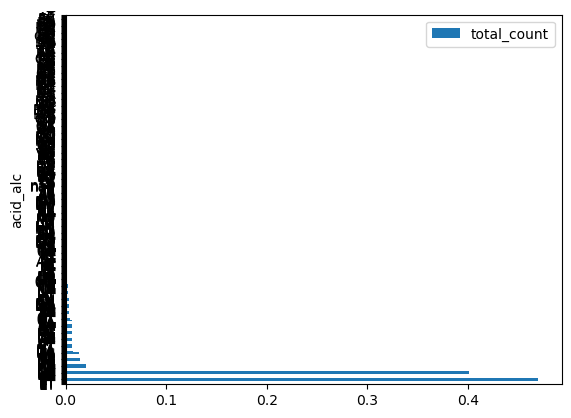

In [43]:
final.set_index('acid_alc').plot(kind='barh', stacked=True)